In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

MOSC_PATH = "../data/mosc_data.csv"
USGS_PATH = "../data/usgs_data/usgs_m4_2005_2025.csv"
AUGER_PATH = "../data/scalers.csv"

def load_moscow():
    df = pd.read_csv(MOSC_PATH, parse_dates=["datetime"])
    return df.set_index("datetime").sort_index()["value"]

def load_earthquakes(min_mag=4.0):
    df = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()

# Loader dla danych Auger (Pierre Auger Observatory, scalers - liczniki
# powierzchniowe czulosci na promieniowanie kosmiczne). Kolumna "time" to
# unix timestamp (sekundy UTC), "rateCorr" to skorygowana stopa zliczen -
# analogicznie do "value" dla Oulu/Moskwy. Zrodlo pliku:
# opendata.auger.org/data.php#scalers (patrz skrypty_dl/cudze/README.md).
def load_auger():
    df = pd.read_csv(AUGER_PATH, usecols=["time", "rateCorr"])
    df["datetime"] = pd.to_datetime(df["time"], unit="s", utc=True).dt.tz_localize(None)
    return df.set_index("datetime").sort_index()["rateCorr"]

cr_auger_15min = load_auger()
print(f"CR Auger (15 min): {len(cr_auger_15min)} pomiarow, "
      f"{cr_auger_15min.index.min()} .. {cr_auger_15min.index.max()}")

# Resample do 6h (rozdzielczosc Moskwy) - dla porownywalnosci z Moskwa/Oulu
# i szybkosci, tak jak zrobiono dla Oulu w 20260716b.ipynb. Wplyw
# rozdzielczosci binowania zbadany juz osobno (20260716c.ipynb, dla Oulu).
cr_auger = cr_auger_15min.resample("6h").mean()
print(f"CR Auger (6h, po resamplingu): {len(cr_auger)} pomiarow "
      f"({len(cr_auger_15min) / len(cr_auger):.1f}x mniej niz 15 min)")

eq = load_earthquakes(min_mag=4.0)
print(f"EQ (M>=4.0): {len(eq)} zdarzen, {eq.index.min()} .. {eq.index.max()}")


CR Auger (15 min): 463915 pomiarow, 2005-03-30 20:52:30 .. 2020-12-07 23:37:30
CR Auger (6h, po resamplingu): 22925 pomiarow (20.2x mniej niz 15 min)
EQ (M>=4.0): 290945 zdarzen, 2005-01-01 00:47:34.620000 .. 2025-01-31 23:57:39.481000


In [2]:
def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)

    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


def full_d_scan(cr, eq, t0, P_days, m, dt_days, d_range):
    return {d: cosmoseismic_stat(cr, eq, t0, P_days, d, m, dt_days)["PCDF"] for d in d_range}


def circular_shift_eq(eq, rng):
    start, end = eq.index.min(), eq.index.max()
    span = end - start
    shift = pd.Timedelta(seconds=int(rng.uniform(0, span.total_seconds())))
    new_idx = (start + ((eq.index - start + shift) % span)).astype(eq.index.dtype)
    return pd.Series(eq.values, index=new_idx).sort_index()


t0 = pd.Timestamp("2013-11-14 07:00:00")  # ten sam t0 co dla Moskwy/Oulu (walidacja artykulu)


In [3]:
# Test kalibracyjny (czas 1 symulacji) przed pelnym MC - jak dla Oulu.
import sys, time
sys.path.insert(0, "..")
from mc_parallel import run_mc_parallel

t_scan = time.time()
sim_auger = full_d_scan(cr_auger, eq, t0, 1675, 4.0, 15, range(1, 31))
print(f"pelny full_d_scan (Auger 6h, d=1..30): {time.time() - t_scan:.2f} s")
best_pcdf_auger = min(sim_auger.values())
print(f"best_pcdf(Auger 6h, t0 jak dla Moskwy/Oulu, bez shift) = {best_pcdf_auger:.3e}")

n_calib = 20
t_mc = time.time()
mc_calib = run_mc_parallel(
    cr_auger, eq, t0, 1675, 4.0, 15, n_calib,
    full_d_scan_fn=full_d_scan, circular_shift_fn=circular_shift_eq,
    base_seed=42,
)
elapsed_calib = time.time() - t_mc
per_sim_auger = elapsed_calib / n_calib
print(f"n_sims={n_calib} rownolegle: {elapsed_calib:.1f} s ({per_sim_auger*1000:.0f} ms/symulacje)")
print(f"ekstrapolacja na n=1e4: {per_sim_auger * 1e4 / 60:.1f} min")
print(f"ekstrapolacja na n=1e5: {per_sim_auger * 1e5 / 60:.1f} min")


pelny full_d_scan (Auger 6h, d=1..30): 0.45 s
best_pcdf(Auger 6h, t0 jak dla Moskwy/Oulu, bez shift) = 2.482e-04
n_sims=20 rownolegle: 1.3 s (63 ms/symulacje)
ekstrapolacja na n=1e4: 10.4 min
ekstrapolacja na n=1e5: 104.2 min


In [4]:
# Pelny Monte Carlo dla Auger (6h) - juz odpalone (n_sims=10000, 523.5s),
# wynik na dysku. Blok symulacji zakomentowany - wczytujemy zapisany .npy
# zamiast liczyc od nowa.
n_sims = 10000
save_path = f"../results/mc_minima_auger_n{n_sims}.npy"

# t_start = time.time()
# mc_minima_auger = run_mc_parallel(
#     cr_auger, eq, t0, 1675, 4.0, 15, n_sims,
#     full_d_scan_fn=full_d_scan, circular_shift_fn=circular_shift_eq,
#     base_seed=42, save_path=save_path,
# )
# elapsed = time.time() - t_start
# print(f"n_sims={n_sims} w {elapsed:.1f} s ({elapsed / n_sims * 1000:.1f} ms/symulacje)")
# print(f"wynik zapisany do {save_path}")

mc_minima_auger = np.load(save_path)
print(f"wczytano {len(mc_minima_auger)} minimow spod H0 z {save_path}")

p_global_auger = (mc_minima_auger <= best_pcdf_auger).mean()
p_global_auger_floor = max(p_global_auger, 1 / n_sims)
sigma_auger = norm.isf(p_global_auger_floor)
print(f"p_global = {p_global_auger:.4f}, floor <= {p_global_auger_floor:.4f} (~{sigma_auger:.2f} sigma)")
print(f"mediana minimow spod H0: {np.median(mc_minima_auger):.3e}, "
      f"ekstremalne minimum: {np.min(mc_minima_auger):.3e}")


wczytano 10000 minimow spod H0 z ../results/mc_minima_auger_n10000.npy
p_global = 0.0288, floor <= 0.0288 (~1.90 sigma)
mediana minimow spod H0: 3.096e-02, ekstremalne minimum: 7.666e-08


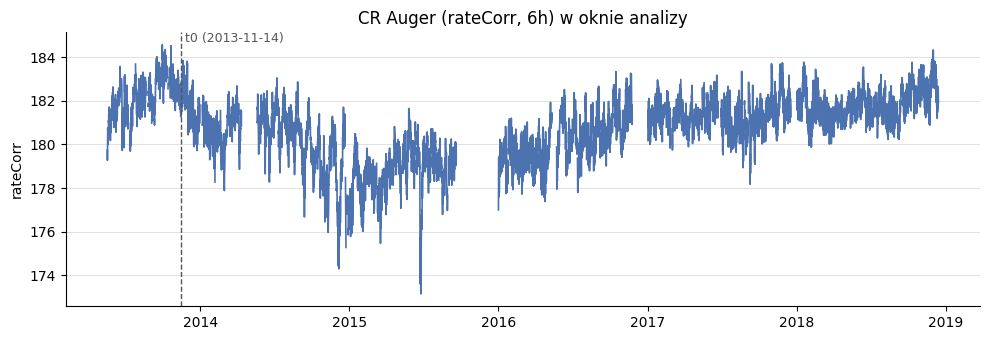

In [5]:
# Wizualizacja 1: szereg czasowy CR Auger (6h) w oknie analizy (t0 .. t0+P_days),
# zaznaczone t0.
P_days = 1675
window_start, window_end = t0 - pd.Timedelta(days=180), t0 + pd.Timedelta(days=P_days) + pd.Timedelta(days=180)
cr_window = cr_auger[(cr_auger.index >= window_start) & (cr_auger.index <= window_end)]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(cr_window.index, cr_window.values, color="#4C72B0", linewidth=1.2)
ax.axvline(t0, color="#555555", linewidth=1, linestyle="--")
ax.text(t0, ax.get_ylim()[1], " t0 (2013-11-14)", va="top", ha="left", color="#555555", fontsize=9)
ax.set_title("CR Auger (rateCorr, 6h) w oknie analizy")
ax.set_ylabel("rateCorr")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#DDDDDD", linewidth=0.6)
fig.tight_layout()
plt.show()


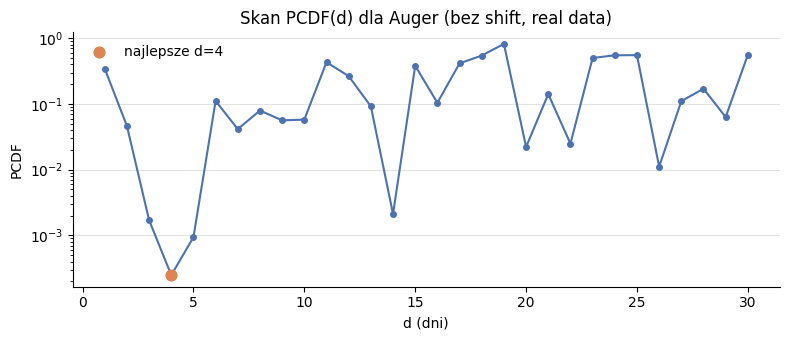

In [6]:
# Wizualizacja 2: PCDF(d) - skan okna d=1..30 dni, najlepsze d podkreslone.
d_values = list(sim_auger.keys())
pcdf_values = list(sim_auger.values())
best_d = min(sim_auger, key=sim_auger.get)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(d_values, pcdf_values, color="#4C72B0", linewidth=1.5, marker="o", markersize=4)
ax.scatter([best_d], [sim_auger[best_d]], color="#DD8452", s=60, zorder=5, label=f"najlepsze d={best_d}")
ax.set_yscale("log")
ax.set_xlabel("d (dni)")
ax.set_ylabel("PCDF")
ax.set_title("Skan PCDF(d) dla Auger (bez shift, real data)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#DDDDDD", linewidth=0.6)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


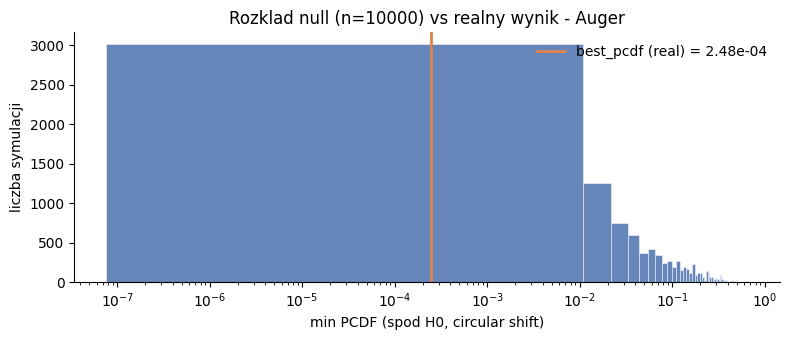

In [7]:
# Wizualizacja 3: rozklad minimow PCDF spod H0 (Monte Carlo, circular shift)
# vs zmierzona wartosc na realnych danych (best_pcdf_auger).
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(mc_minima_auger, bins=60, color="#4C72B0", alpha=0.85, edgecolor="white", linewidth=0.4)
ax.axvline(best_pcdf_auger, color="#DD8452", linewidth=2,
           label=f"best_pcdf (real) = {best_pcdf_auger:.2e}")
ax.set_xscale("log")
ax.set_xlabel("min PCDF (spod H0, circular shift)")
ax.set_ylabel("liczba symulacji")
ax.set_title(f"Rozklad null (n={len(mc_minima_auger)}) vs realny wynik - Auger")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


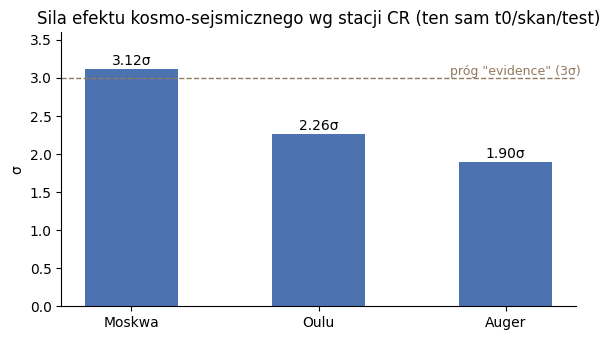

In [8]:
# Wizualizacja 4: porownanie sigma miedzy 3 stacjami (ta sama metodologia,
# rozdzielczosc 6h). Wartosci Moskwa/Oulu z 20260716.txt (20260715.ipynb,
# 20260716b.ipynb) - wpisane tu jako stale referencyjne, nie przeliczane
# na nowo w tym notebooku.
stacje = ["Moskwa", "Oulu", "Auger"]
sigmy = [3.12, 2.26, sigma_auger]

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(stacje, sigmy, color="#4C72B0", width=0.5)
ax.axhline(3.0, color="#937860", linewidth=1, linestyle="--")
ax.text(2.4, 3.0, " próg \"evidence\" (3σ)", va="bottom", ha="right", color="#937860", fontsize=9)
for bar, val in zip(bars, sigmy):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.05, f"{val:.2f}σ", ha="center", fontsize=10)
ax.set_ylabel("σ")
ax.set_title("Sila efektu kosmo-sejsmicznego wg stacji CR (ten sam t0/skan/test)")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, 3.6)
fig.tight_layout()
plt.show()
